In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
sns.set_theme(style='ticks', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)

In [5]:
df = pd.read_csv('Titanic-Dataset.csv')
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


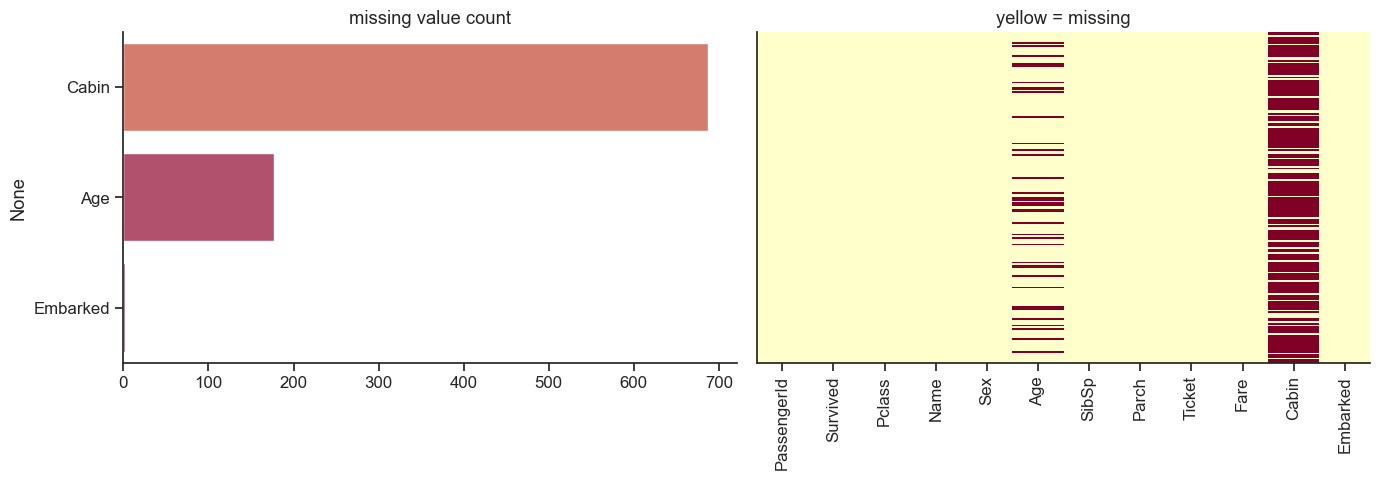

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=missing.values, y=missing.index,
            hue=missing.index, palette='flare',
            legend=False, ax=axes[0])
axes[0].set_title('missing value count')

sns.heatmap(df.isnull().sample(min(200, len(df))),
            cbar=False, cmap='YlOrRd',
            yticklabels=False, ax=axes[1])
axes[1].set_title('yellow = missing')

sns.despine()
plt.tight_layout()
plt.show()

In [7]:
df = df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'])
df = df.drop_duplicates()

df['Age']      = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print(df.isnull().sum())


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [8]:
df['Sex']        = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked']   = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)

scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

In [11]:
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100, max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)


RandomForestClassifier(max_depth=5, random_state=42)

accuracy : 80.13%

              precision    recall  f1-score   support

        died       0.78      0.91      0.84        91
    survived       0.84      0.65      0.73        65

    accuracy                           0.80       156
   macro avg       0.81      0.78      0.79       156
weighted avg       0.81      0.80      0.80       156



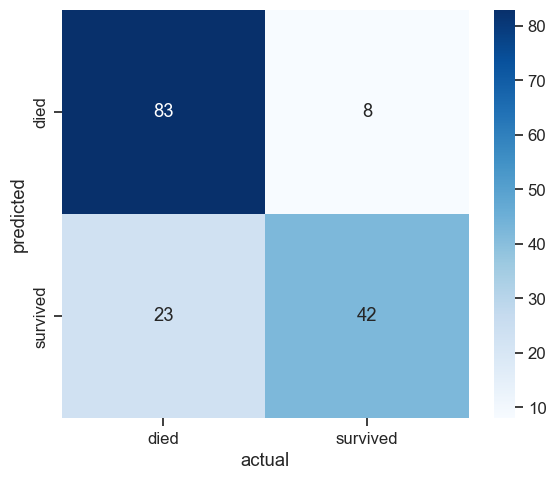

In [12]:
y_pred = model.predict(X_test)

print(f'accuracy : {accuracy_score(y_test, y_pred):.2%}')
print()
print(classification_report(y_test, y_pred,
      target_names=['died', 'survived']))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['died', 'survived'],
            yticklabels=['died', 'survived'])
plt.ylabel('predicted')
plt.xlabel('actual')
plt.tight_layout()
plt.show()